In [ ]:
#Kaan Algür - GRU
#20.12.2025

In [1]:
#İmport necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Actice device: {device}")

Actice device: cpu


In [3]:
#upload colab file after that upload csv file
try:
    df = pd.read_csv('emails.csv')
    print("dataset loaded.")
except:
    print("ERROR: The file 'emails.csv' could not be found. Please upload the file from the left panel.")

# Clear and tokenizer function implemented
def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # only hold letter
    return text.split()

#Vocab creation
all_words = []
for text in df['text']:
    all_words.extend(tokenize(text))

word_counts = Counter(all_words)
# take the 5000 most frequently used words. (Hyperparameter)
vocab = sorted(word_counts, key=word_counts.get, reverse=True)[:5000]
word_to_index = {word: i+1 for i, word in enumerate(vocab)} # 0 for padding

def text_to_indices(text, max_len=100):
    tokens = tokenize(text)
    indices = [word_to_index.get(token, 0) for token in tokens] # unknown words 0
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices)) # Padding
    else:
        indices = indices[:max_len] # Truncate
    return indices

# Transform data
X = [text_to_indices(t) for t in df['text']]
y = df['spam'].values # (1: spam, 0: normal)

# Train - Val - Test Split (%70 Train, %15 Val, %15 Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# PyTorch Dataset class
class EmailDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = torch.LongTensor(X_data)
        self.y_data = torch.FloatTensor(y_data)

    def __len__(self):
        return len(self.X_data)

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

# Create DataLoader
batch_size = 64
train_loader = DataLoader(EmailDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(EmailDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(EmailDataset(X_test, y_test), batch_size=batch_size)

dataset loaded.


An enhanced start to the training...
Epoch 1/15 | Loss: 0.3380 | Val Acc: 0.9220 | LR: 0.001000
--> New Best Result! Model Saved. (Acc: 0.9220)
Epoch 2/15 | Loss: 0.1322 | Val Acc: 0.9430 | LR: 0.001000
--> New Best Result! Model Saved. (Acc: 0.9430)
Epoch 3/15 | Loss: 0.0671 | Val Acc: 0.9569 | LR: 0.001000
--> New Best Result! Model Saved. (Acc: 0.9569)
Epoch 4/15 | Loss: 0.0249 | Val Acc: 0.9558 | LR: 0.001000
Epoch 5/15 | Loss: 0.0242 | Val Acc: 0.9697 | LR: 0.001000
--> New Best Result! Model Saved. (Acc: 0.9697)
Epoch 6/15 | Loss: 0.0194 | Val Acc: 0.9511 | LR: 0.001000
Epoch 7/15 | Loss: 0.0099 | Val Acc: 0.9662 | LR: 0.001000
Epoch 8/15 | Loss: 0.0026 | Val Acc: 0.9802 | LR: 0.001000
--> New Best Result! Model Saved. (Acc: 0.9802)
Epoch 9/15 | Loss: 0.0016 | Val Acc: 0.9767 | LR: 0.001000
Epoch 10/15 | Loss: 0.0004 | Val Acc: 0.9790 | LR: 0.001000
Epoch 11/15 | Loss: 0.0002 | Val Acc: 0.9779 | LR: 0.000500
Epoch 12/15 | Loss: 0.0002 | Val Acc: 0.9802 | LR: 0.000500
Epoch 13/15 

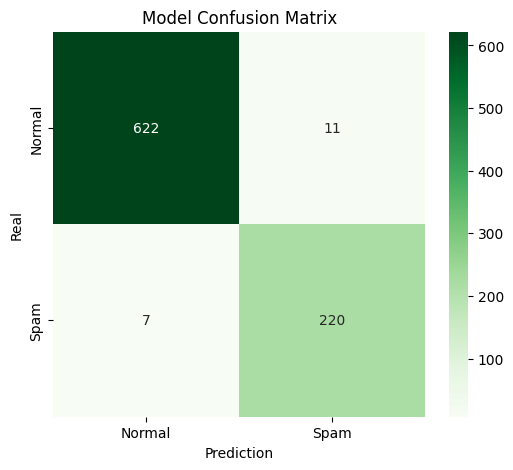

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Swish remains same
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ProSpamGruModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout_prob=0.5):
        super(ProSpamGruModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # We increased the number of Conv1d filters from 128 to 256 (to capture more features).
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=256, kernel_size=3, padding=1)
        self.swish = Swish()
        self.dropout = nn.Dropout(dropout_prob)

        # Critical Change 1: Bidirectional=True
        # GRU will now read the sentence both forwards and backwards.
        self.gru = nn.GRU(input_size=256, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True,
                          dropout=0.3 if num_layers > 1 else 0,
                          bidirectional=True)

        # The output layer is now twice the size (because it's bidirectional).
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.swish(x)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)

        out, h_n = self.gru(x)

        # Because the model is bidirectional, the final forward and backward hidden states from the last layer are concatenated to form the representation.

        # The last layer is forward (-2) and backward (-1)
        hidden_forward = h_n[-2, :, :]
        hidden_backward = h_n[-1, :, :]

        # Concatenate
        cat_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)

        x = self.fc(cat_hidden)
        return self.sigmoid(x)

# --- MODEL SETTİNGS ---(Stronger than before)
vocab_size = 5001
embed_dim = 200     # 100 -> 200 (Word vectors are richer)
hidden_dim = 128    # 64 -> 128 (Memory capacity increased)
num_layers = 2      # 2 Layer

model = ProSpamGruModel(vocab_size, embed_dim, hidden_dim, num_layers, dropout_prob=0.5).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Critical Change 2: Scheduler ---
# If the validation loss does not decrease over 2 epochs, halve the learning rate (factor=0.5).
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
# Training Cycle
num_epochs = 15
best_val_acc = 0.0

print("An enhanced start to the training...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(inputs)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total

    # Scheduler Step (Learning Rate setting)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gru_model_pro.pth')
        print(f"--> New Best Result! Model Saved. (Acc: {best_val_acc:.4f})")

# Test
print("\nLoading the best model...")
model.load_state_dict(torch.load('best_gru_model_pro.pth'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predicted = (outputs > 0.5).float()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("-" * 30)
print(f"Test Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("-" * 30)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Spam'], yticklabels=['Normal', 'Spam'])
plt.ylabel('Real')
plt.xlabel('Prediction')
plt.title('Model Confusion Matrix')
plt.show()